# Efficient Transformer Systems: Gated DeltaNet, KDA, and 3:1 hybrids

**Completed controlled reference-path experiment · four-layer nanoGPT decoder · full-epoch training and autoregressive inference**

> This is an engineering research project rather than a completed academic study. I implemented readable recurrent versions of Gated DeltaNet and Kimi Delta Attention, integrated them into a shared nanoGPT backbone, and compared pure and hybrid layer schedules. The experiment tests the implemented operators; it does not claim to reproduce Qwen3-Next or Kimi Linear at production scale.

## 1. Research question and hypotheses

**Under one four-layer nanoGPT training budget, how do pure Gated DeltaNet (GDN), pure Kimi Delta Attention (KDA), and 3:1 recurrent/full-attention schedules trade validation quality, persistent inference-state memory, and reference-path latency against homogeneous MHA, GQA, MQA, and MLA-style baselines?**

This extends the attention-cache experiment from *how K/V is stored* to *whether the token mixer must store the token history at all*.

Hypotheses:

1. **Constant-state hypothesis.** Pure GDN and KDA will replace the token-growing KV cache with a fixed recurrent matrix plus short-convolution history.
2. **Hybrid scaling hypothesis.** A 3:1 hybrid will grow only through its one-in-four full-attention anchor; it is fixed-plus-linear rather than fully constant-memory.
3. **Forgetting-granularity hypothesis.** KDA and GDN will have the same matrix-state size, because KDA changes scalar per-head decay into channel-wise decay rather than shrinking the state.
4. **Quality hypothesis.** The delta-rule inductive bias may improve small-corpus PPL, but a single seed and unmatched parameter counts cannot establish architectural superiority.
5. **KV-sharing ladder hypothesis.** GQA, MQA, and MLA-style attention will reduce the slope of token-growing state relative to MHA, but will not make it context-independent.
6. **Kernel-boundary hypothesis.** A transparent Python token scan will expose the memory law while failing to reproduce the throughput of optimized FLA/FlashKDA CUDA kernels.
7. **Gated-MLA hypothesis.** Gating the current-token MLA output may change quality or compute, but it should not change the latent-cache storage law.

## 2. From linear attention to modern hybrid decoders

The experiment follows this conceptual progression:

1. **Linear attention** stores an associative matrix state rather than every past K/V vector. This gives recurrent decoding whose persistent state does not grow with context. See [Transformers are RNNs](https://arxiv.org/abs/2006.16236).
2. **Gated DeltaNet** combines the delta write rule with an input-dependent forget gate: the delta update corrects a key–value association, while the gate can clear stale global memory. See [Gated Delta Networks](https://arxiv.org/abs/2412.06464) and the [official NVIDIA repository](https://github.com/NVlabs/GatedDeltaNet).
3. **Gated full attention** multiplies the attention output by a learned sigmoid gate before the output projection. This is the full-attention anchor used in the Qwen3-Next-inspired schedule. See [Gated Attention for Large Language Models](https://arxiv.org/abs/2505.06708).
4. **Qwen3-Next** interleaves three GDN layers with one gated full-attention layer. The official description states a 3:1 ratio (75% GDN, 25% attention): [Qwen3-Next blog](https://qwen.ai/blog?id=e34c4305036ce60d55a0791b170337c2b70ae51d).
5. **Kimi Delta Attention** generalizes forgetting from one scalar per head to a vector over key channels, parameterized through low-rank projections. **Kimi Linear** uses a 3:1 schedule of KDA and MLA. See the [Kimi Linear paper](https://arxiv.org/abs/2510.26692) and [official MoonshotAI code](https://github.com/MoonshotAI/Kimi-Linear).
6. **MLA model lineage.** Kimi K2 and Kimi K2.5 use MLA decoders with sparse MoE; K2.5 continues pretraining from K2 and adds a vision encoder. They are not KDA models. See the official [Kimi K2](https://github.com/MoonshotAI/Kimi-K2) and [Kimi K2.5](https://github.com/MoonshotAI/Kimi-K2.5) repositories.
7. **Kimi K3.** The 22 July 2026 launch diagram depicts a 3:1 `KDA x3 -> gated MLA` block, plus Attention Residuals and Stable LatentMoE. This lab implements only the token-mixer schedule as an operator-level approximation. See the [official launch post](https://www.kimi.com/blog/kimi-k3).

The laboratory reproduces the core recurrences, gates, causal short convolutions, state objects, and whole-layer 3:1 schedules. It retains GPT-2 learned positions and the same dense MLP in every variant, so the hybrids are correctly described as **Qwen3-Next-inspired**, **Kimi-Linear-inspired**, and **Kimi-K3-inspired**, not model reproductions. Holding the FFN constant isolates the token mixer; it preserves the attention-state comparison but excludes production MoE quality, active FLOPs, communication, peak memory, and end-to-end latency.

![Implemented hybrid schedules](../results/hybrid_architectures.png)

## 3. Exact recurrent equations implemented

For clarity, the implementation stores each head state as $S_t\in\mathbb{R}^{d_k\times d_v}$. After linear projection, causal depthwise convolution, SiLU, and L2 normalization of $q_t$ and $k_t$, the shared delta update is

$$\bar S_t = \mathcal{D}_t(S_{t-1}),$$

$$e_t = v_t-k_t^\top\bar S_t,$$

$$S_t = \bar S_t + \beta_t k_t e_t^\top, \qquad \beta_t=\sigma(W_\beta x_t),$$

$$o_t = \frac{q_t^\top S_t}{\sqrt{d_k}}.$$

At the recurrent-rule level, the mechanisms differ in the decay operator:

- **GDN:** $\mathcal{D}_t(S)=\alpha_{t,h}S$, one scalar decay for each token and head.
- **KDA:** $\mathcal{D}_t(S)=\operatorname{Diag}(\boldsymbol{\alpha}_{t,h})S$, one decay value for every key channel.

The stable log-decay parameterization is

$$\log\alpha_t=-\exp(A_{\log})\,\operatorname{softplus}(a_t+\mathrm{dt\_bias}),$$

where GDN uses $a_t=W_\alpha x_t$ and KDA uses a low-rank $a_t=W_{up}W_{down}x_t$. Thus $0<\alpha_t<1$. The recurrent matrix accumulates in FP32. Finally, each head applies RMSNorm and an output gate before $W_O$; the GDN path uses a full-rank SiLU gate, while the KDA path uses a low-rank sigmoid gate. Therefore, the end-to-end GDN/KDA PPL comparison is not an isolated ablation of decay granularity.

For a batch of size $B$, persistent state per recurrent layer is

$$B\left(Hd_kd_v + 3(c-1)d_{model}\right)\text{ elements},$$

where the first term is the recurrent matrix and the second is Q/K/V convolution history. It is independent of context length.

## 4. Nine controlled variants

| Result key | Four-layer token-mixer schedule | Persistent-state law | Purpose |
|---|---|---|---|
| `MHA_4L` | MHA × 4 | $4096T$ bytes | Standard full-history baseline |
| `GQA_4L` | GQA × 4, 2 KV heads | $2048T$ bytes | Shared-KV grouped baseline |
| `MQA_4L` | MQA × 4, 1 KV head | $1024T$ bytes | Single shared-KV baseline |
| `MLA_4L` | MLA-style × 4 | $512T$ bytes | Compressed token-growing baseline |
| `GDN_4L` | GDN × 4 | 83,968 fixed bytes | Pure scalar-decay recurrent model |
| `KDA_4L` | KDA × 4 | 83,968 fixed bytes | Pure channel-wise-decay recurrent model |
| `GDN_GA_3TO1` | GDN → GDN → GDN → gated MHA | $62,976+1024T$ bytes | Qwen3-Next-inspired 3:1 schedule |
| `KDA_MLA_3TO1` | KDA → KDA → KDA → MLA-style | $62,976+128T$ bytes | Kimi-Linear-inspired 3:1 schedule |
| `K3_KDA_GMLA_3TO1` | KDA → KDA → KDA → gated MLA-style | $62,976+128T$ bytes | Kimi-K3-inspired gate ablation |

$T$ is the number of cached tokens, batch size is one, and byte counts are taken from the actual FP32 cache/state tensors created by this implementation.

## 5. Full-epoch protocol and metrics

All nine models use four decoder layers, width 128, four query heads, context 64 during training, block size 192, dropout 0, AdamW with learning rate $3\times10^{-4}$ and weight decay 0.1, gradient clipping at 1.0, and seed 2026. GQA uses two KV heads and MQA uses one. Non-attention backbone weights start identically. The common AdamW group applies weight decay to all parameters, including `A_log` and `dt_bias`; official recurrent recipes exclude those gate parameters, so this is a controlled shared optimizer rather than their exact grouping.

The character-level Shakespeare training split contains 1,003,854 tokens. One **full epoch** visits every one of the 15,685 complete non-overlapping 64-token windows exactly once, including the final partial batch: 981 optimizer steps and 1,003,840 training tokens per model. Validation uses the same deterministic batches at common checkpoints.

Metrics:

- **Quality:** validation cross-entropy and character-level perplexity, $\mathrm{PPL}=\exp(\mathrm{loss})$; lower is better.
- **Training:** total parameters, token-mixer parameters, training tokens/second.
- **Inference:** prefill time, cached and full-recomputation p50 latency, decode tokens/second, and caching speedup.
- **Persistent state:** measured occupied bytes at executed contexts plus the exact `fixed_bytes + bytes_per_token × T` law.

Inference uses prompt lengths 32, 64, and 128, followed by 32 decoded tokens, one warm-up, and seven measured repetitions on one CPU thread. Cached/full numerical equivalence, convolution-history equivalence, causality, and constant-state behavior are covered by the project tests.

In [1]:
from pathlib import Path
import json
import sys

import pandas as pd
from IPython.display import Image, Markdown, display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'research').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from research.experiment import ExperimentConfig, default_data_path
from research.hybrid_experiment import run_hybrid_experiment
from research.plot_hybrid import LABELS, ORDER, state_projection

RESULTS_PATH = PROJECT_ROOT / 'results' / 'hybrid_linear_attention_cpu.json'
FIGURE_DIR = PROJECT_ROOT / 'results'
FORCE_RERUN = False  # Keep False to use the completed full-epoch run.

In [2]:
lab_config = ExperimentConfig(
    steps=250, eval_interval=200, eval_batches=12,
    batch_size=16, train_context=64,
    block_size=192, n_layer=4, n_head=4, n_embd=128,
    gqa_n_kv_heads=2, mla_latent_rank=32,
    delta_conv_kernel=4, kda_gate_rank=32,
    inference_prompt_lengths=(32, 64, 128),
    inference_decode_tokens=32, inference_repeats=7,
    num_threads=1, seed=2026,
    training_mode='full_epoch', epochs=1,
)

if FORCE_RERUN:
    results = run_hybrid_experiment(
        default_data_path(), RESULTS_PATH, lab_config, device_name='auto'
    )
    load_status = 'Experiment rerun completed.'
else:
    if not RESULTS_PATH.exists():
        raise FileNotFoundError(
            f'{RESULTS_PATH} is missing; set FORCE_RERUN=True only if a full rerun is intended.'
        )
    results = json.loads(RESULTS_PATH.read_text(encoding='utf-8'))
    load_status = 'Loaded completed JSON; no training was run by this notebook execution.'

print(load_status)
display(pd.Series(results['environment'], name='value').to_frame())

Loaded completed JSON; no training was run by this notebook execution.


,value
timestamp_utc,2026-07-22T16:31:17.531989+00:00
python,3.14.2
torch,2.10.0
platform,macOS-26.5.1-arm64-arm-64bit-Mach-O
machine,arm64
processor,arm
device,cpu
cuda_available,False
mps_available,False
torch_num_threads,1


In [3]:
longest_prompt = max(
    row['prompt_length']
    for variant in results['variants']
    for row in variant['inference']
)
summary_rows = []
for variant in sorted(results['variants'], key=lambda row: ORDER.index(row['variant'])):
    inference = next(
        row for row in variant['inference']
        if row['prompt_length'] == longest_prompt
    )
    layout = variant['cache_layout']
    summary_rows.append({
        'variant': LABELS[variant['variant']],
        'parameters': variant['parameter_count'],
        'token_mixer_parameters': variant['attention_parameter_count'],
        'val_PPL': round(variant['final_validation_perplexity'], 2),
        'train_tok/s': round(variant['training_tokens_per_second']),
        'cached_ms/token': round(inference['cached_decode_ms_per_token']['p50'], 3),
        'recompute_ms/token': round(inference['recompute_decode_ms_per_token']['p50'], 3),
        'state_at_160_KiB': round(inference['cache_occupied_bytes'] / 1024, 1),
        'fixed_state_KiB': round(layout['fixed_bytes'] / 1024, 1),
        'growing_bytes/token': layout['bytes_per_token'],
    })
summary = pd.DataFrame(summary_rows).set_index('variant')
summary

,parameters,token_mixer_parameters,val_PPL,train_tok/s,cached_ms/token,recompute_ms/token,state_at_160_KiB,fixed_state_KiB,growing_bytes/token
variant,,,,,,,,,
MHA (4L),821632,262144,8.44,26939,0.388,2.989,640.0,0.0,4096
"GQA (4L, 2 KV heads)",756096,196608,8.48,26310,0.426,2.950,320.0,0.0,2048
"MQA (4L, 1 KV head)",723328,163840,8.84,27057,0.415,2.911,160.0,0.0,1024
MLA-style (DeepSeek-V2; Kimi K2/K2.5 lineage),739968,180480,9.36,26739,0.429,2.958,80.0,0.0,512
Gated DeltaNet (4L pure),897952,338464,5.91,2954,3.701,30.815,82.0,82.0,0
KDA (4L pure),896400,336912,6.15,2857,3.696,30.187,82.0,82.0,0
GDN + gated MHA (Qwen3-Next-inspired),895256,335768,6.11,3772,2.723,22.864,221.5,61.5,1024
KDA + MLA-style (Kimi Linear-inspired),857292,297804,6.24,3723,2.763,23.320,81.5,61.5,128
KDA + gated MLA (Kimi K3-inspired*),873676,314188,6.23,3683,2.838,23.721,81.5,61.5,128


## 6. Measured training and inference results

The following figures come from the saved completed run. Training curves share the same full-epoch token count. Inference points are executions inside the 192-token model window.

### Matched full-epoch training

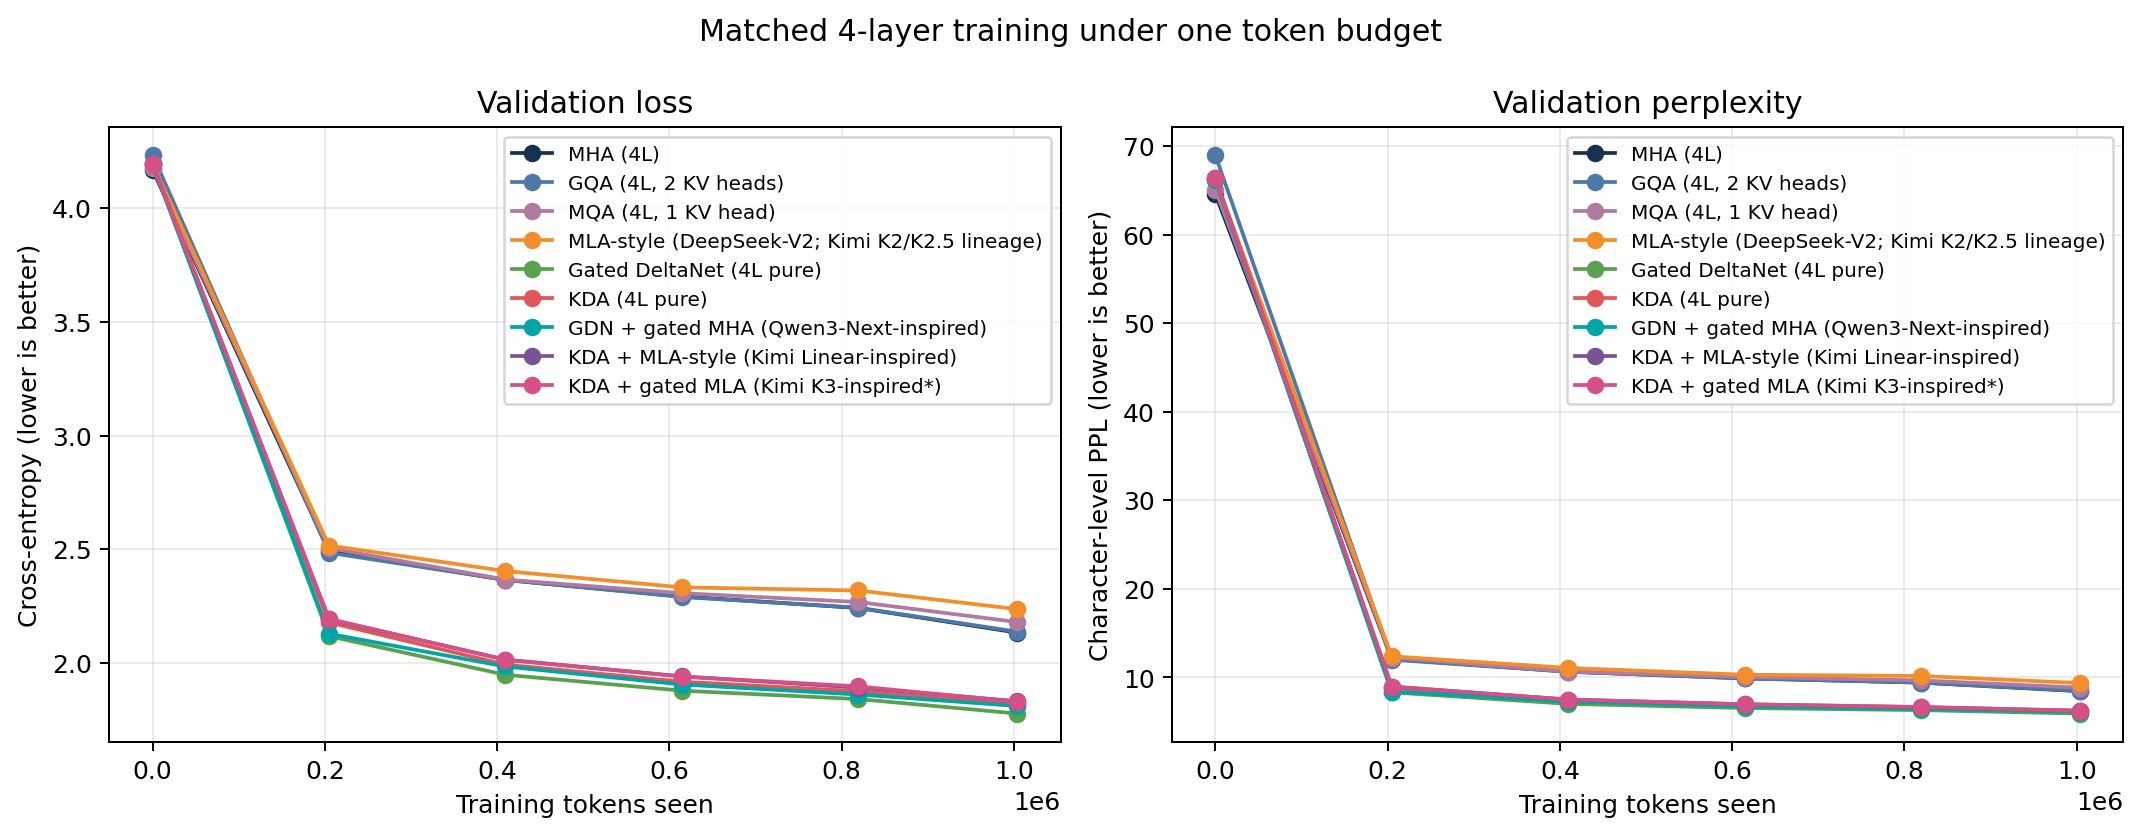

### Autoregressive inference on the readable reference paths

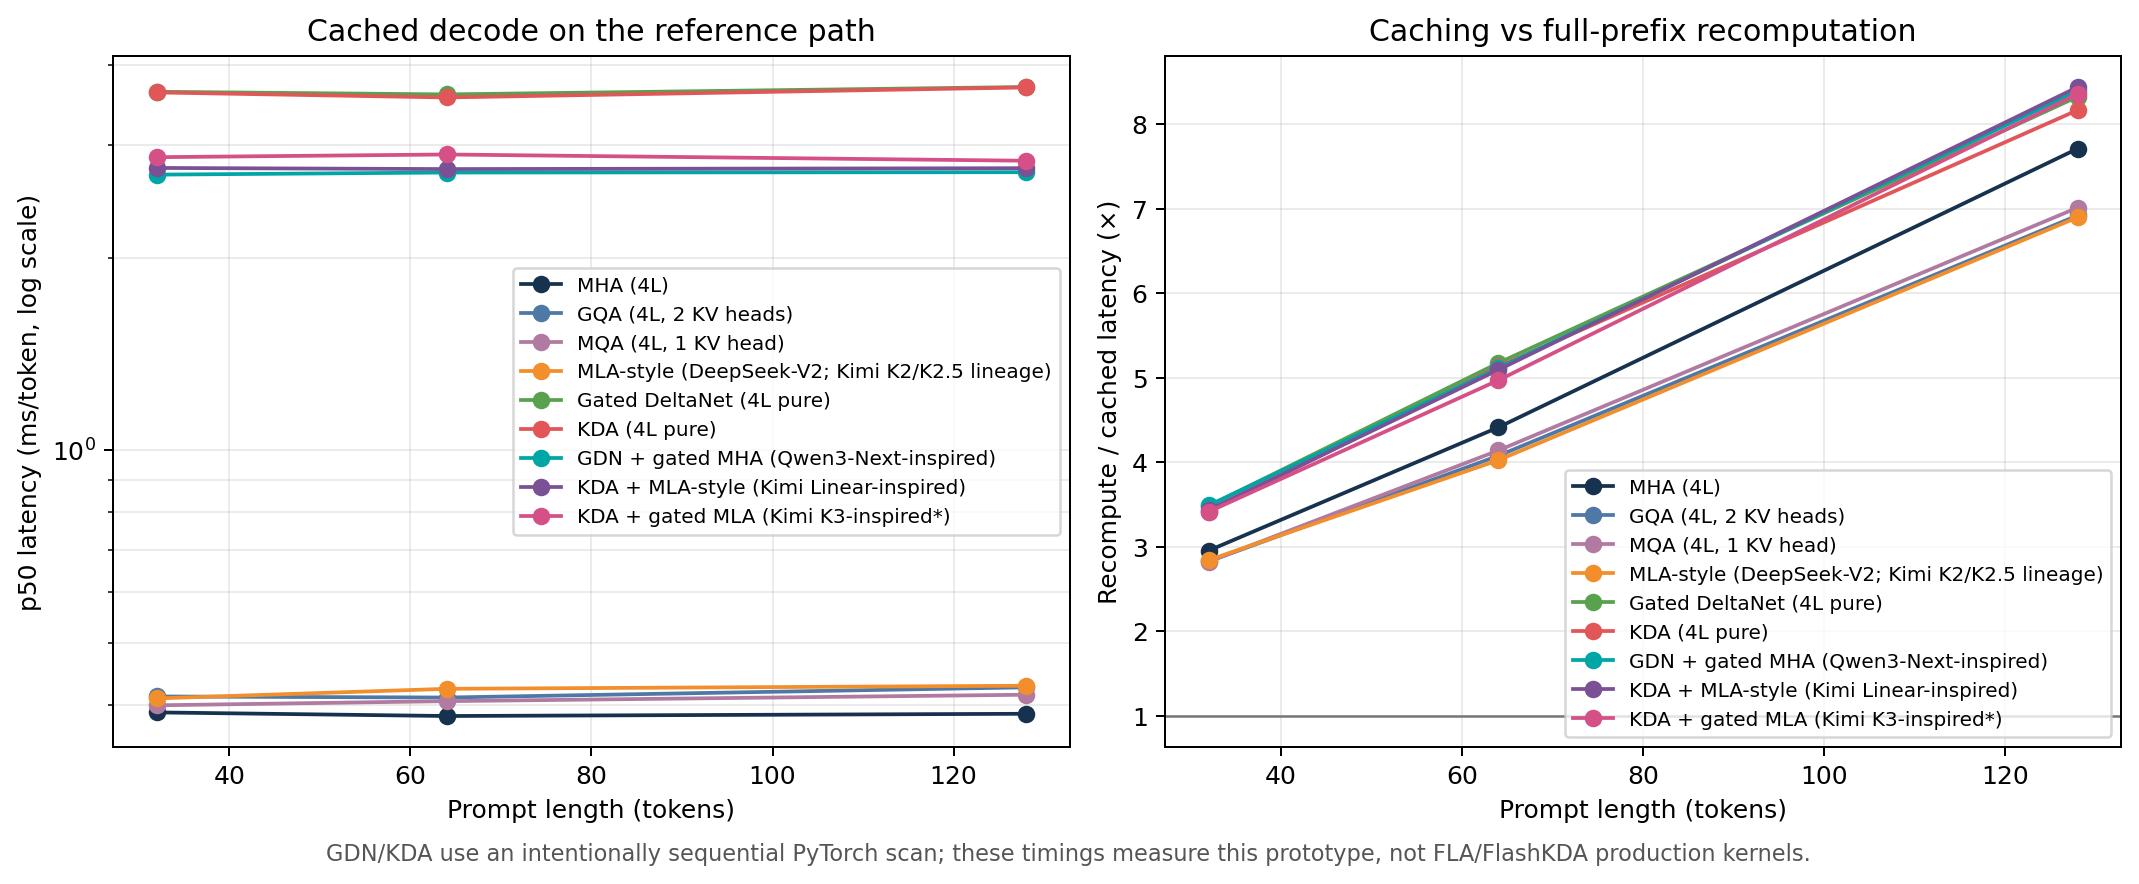

In [4]:
for title, filename in (
    ('Matched full-epoch training', 'hybrid_training_curves.png'),
    ('Autoregressive inference on the readable reference paths', 'hybrid_inference_latency.png'),
):
    display(Markdown(f'### {title}'))
    display(Image(filename=FIGURE_DIR / filename))

## 7. Long-context persistent state

This is the main systems result. Crosses and solid segments correspond to instantiated cache/state objects inside the executed window. Dashed extensions apply the exact measured layout law to longer contexts. They answer **how much persistent inference state would be stored**, not how accurate or fast a 128K execution would be.

Pure GDN and KDA are flat because only the recurrent matrix and three short-convolution histories persist. Each hybrid contains one token-growing anchor, so its slope is one quarter of the corresponding four-layer anchor stack.

,state_MiB,sequences_per_1_gib,fixed_bytes,bytes_per_token
variant,,,,
MHA (4L),512.00,2,0,4096
"GQA (4L, 2 KV heads)",256.00,4,0,2048
"MQA (4L, 1 KV head)",128.00,8,0,1024
MLA-style (DeepSeek-V2; Kimi K2/K2.5 lineage),64.00,16,0,512
Gated DeltaNet (4L pure),0.08,12787,83968,0
KDA (4L pure),0.08,12787,83968,0
GDN + gated MHA (Qwen3-Next-inspired),128.06,7,62976,1024
KDA + MLA-style (Kimi Linear-inspired),16.06,63,62976,128
KDA + gated MLA (Kimi K3-inspired*),16.06,63,62976,128


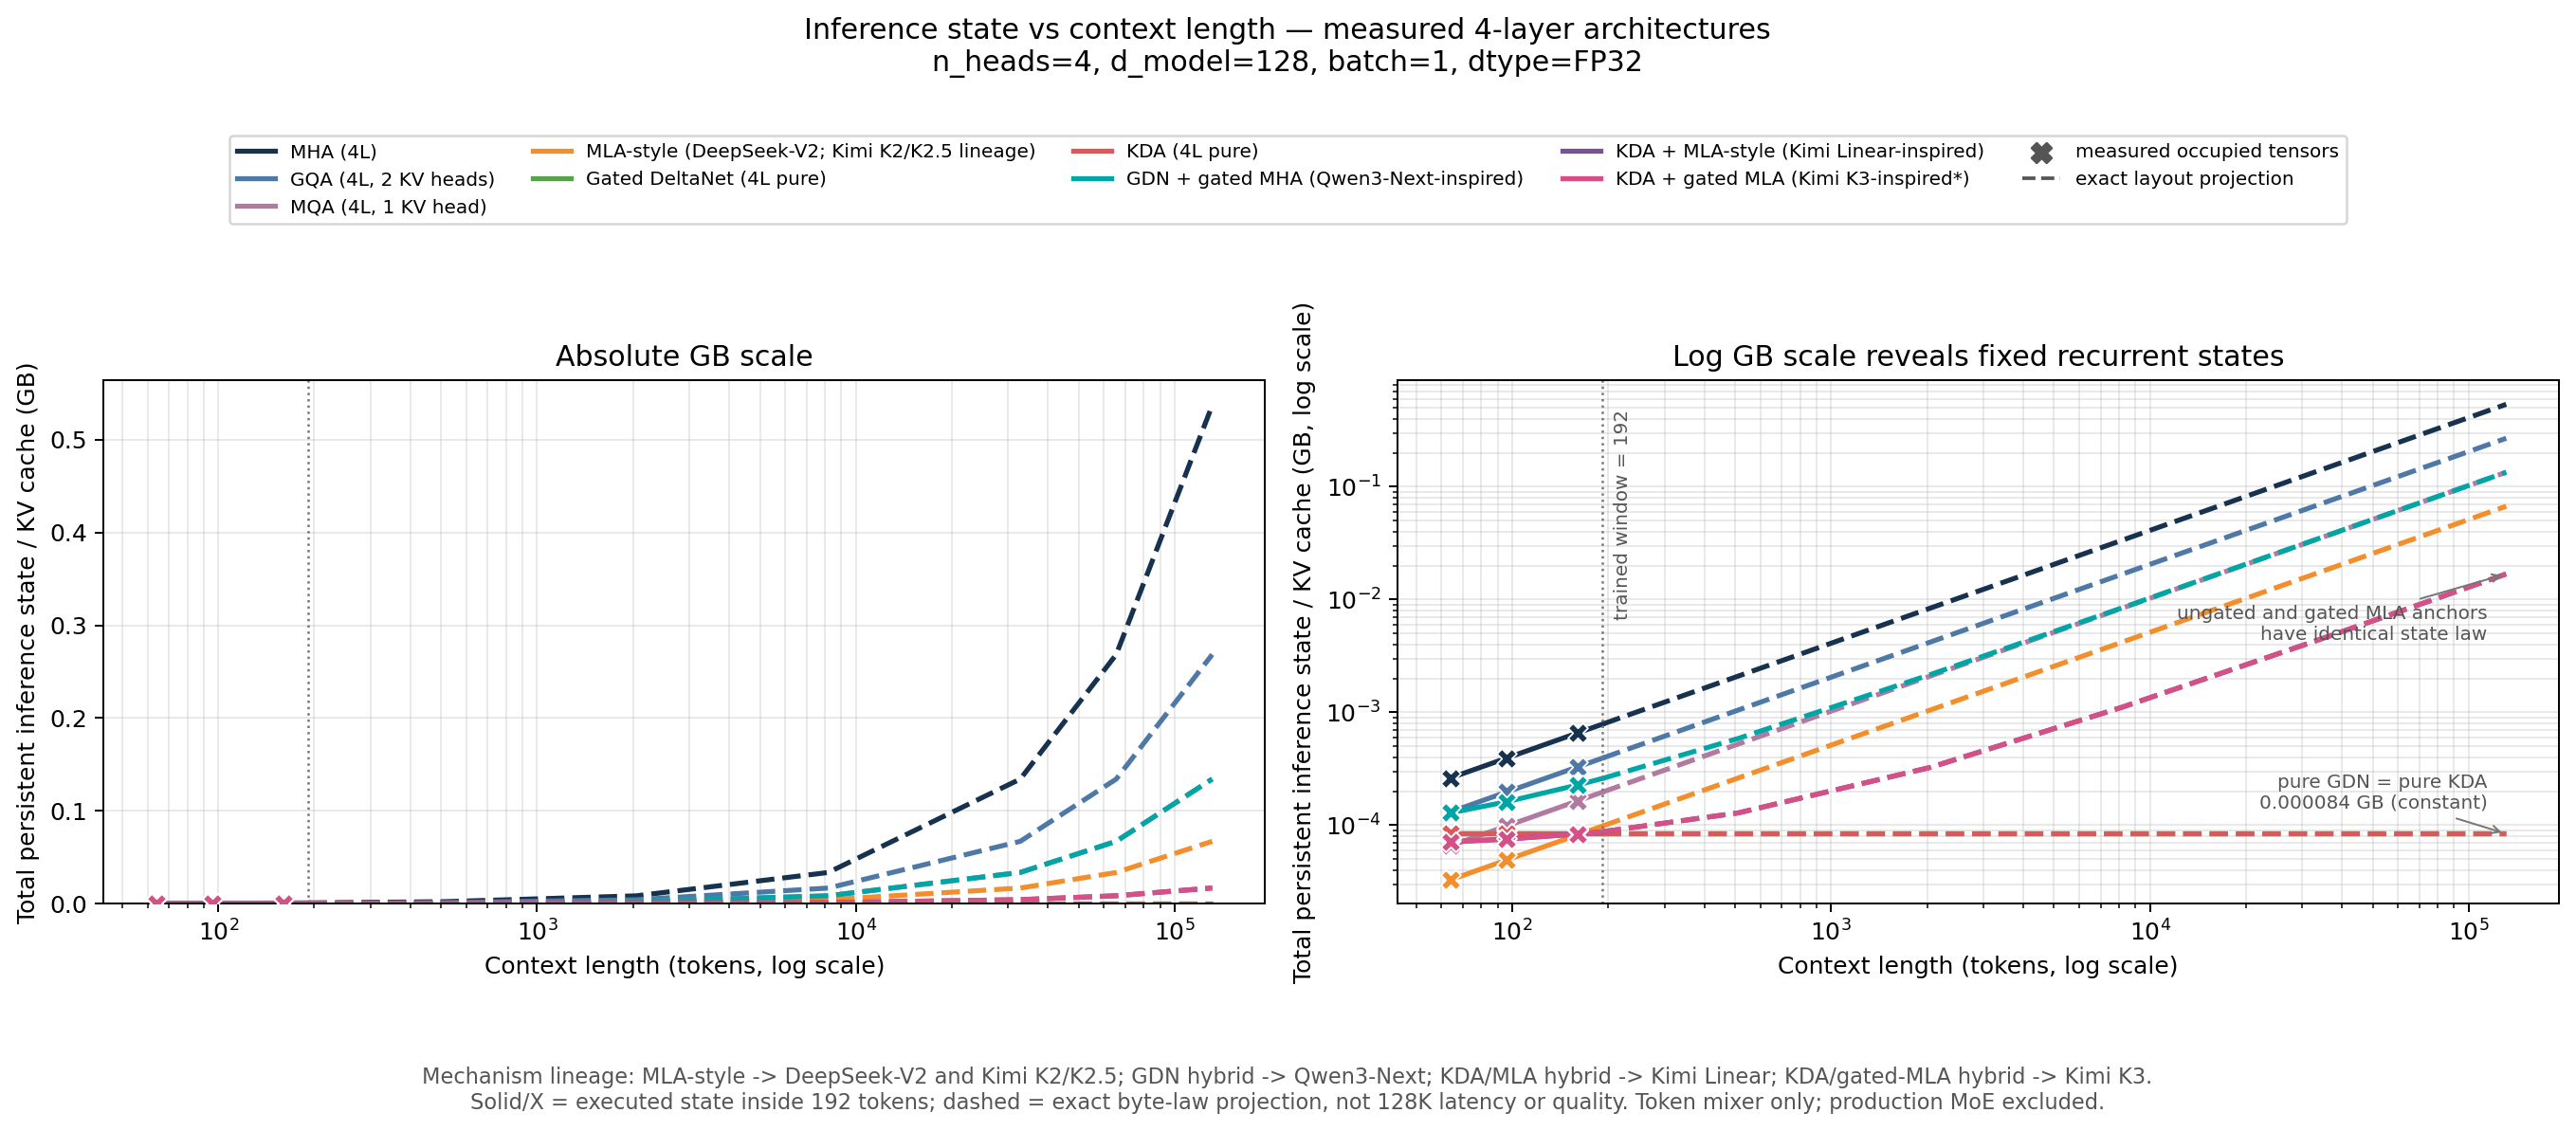

In [5]:
projection = pd.DataFrame(state_projection(results))
projection_128k = projection[projection['context_tokens'] == 131_072].copy()
projection_128k['variant'] = projection_128k['variant'].map(LABELS)
projection_128k['state_MiB'] = (projection_128k['state_bytes'] / 1024**2).round(3)
display(
    projection_128k[
        ['variant', 'state_MiB', 'sequences_per_1_gib', 'fixed_bytes', 'bytes_per_token']
    ].set_index('variant')
)
display(Image(filename=FIGURE_DIR / 'total_state_vs_context_gb.png'))

### State capacity and concurrency

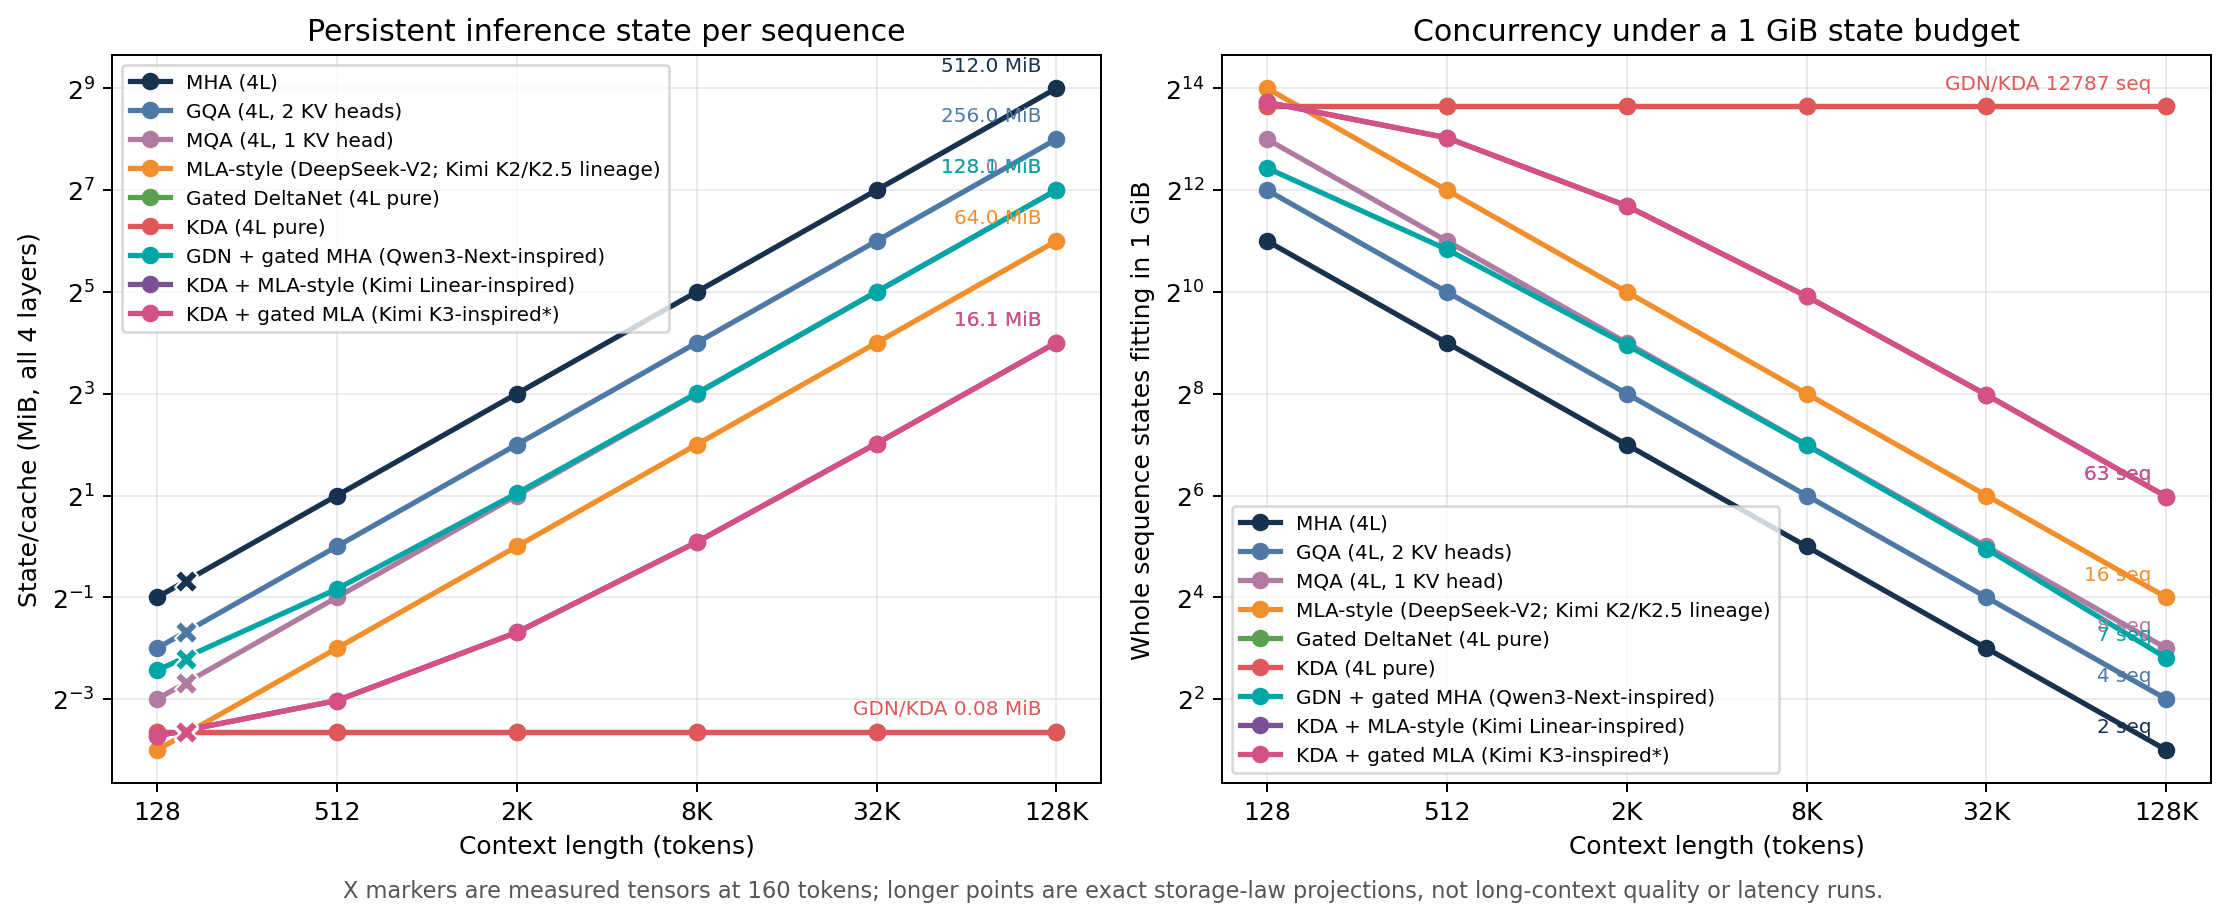

### Fixed versus token-growing state composition

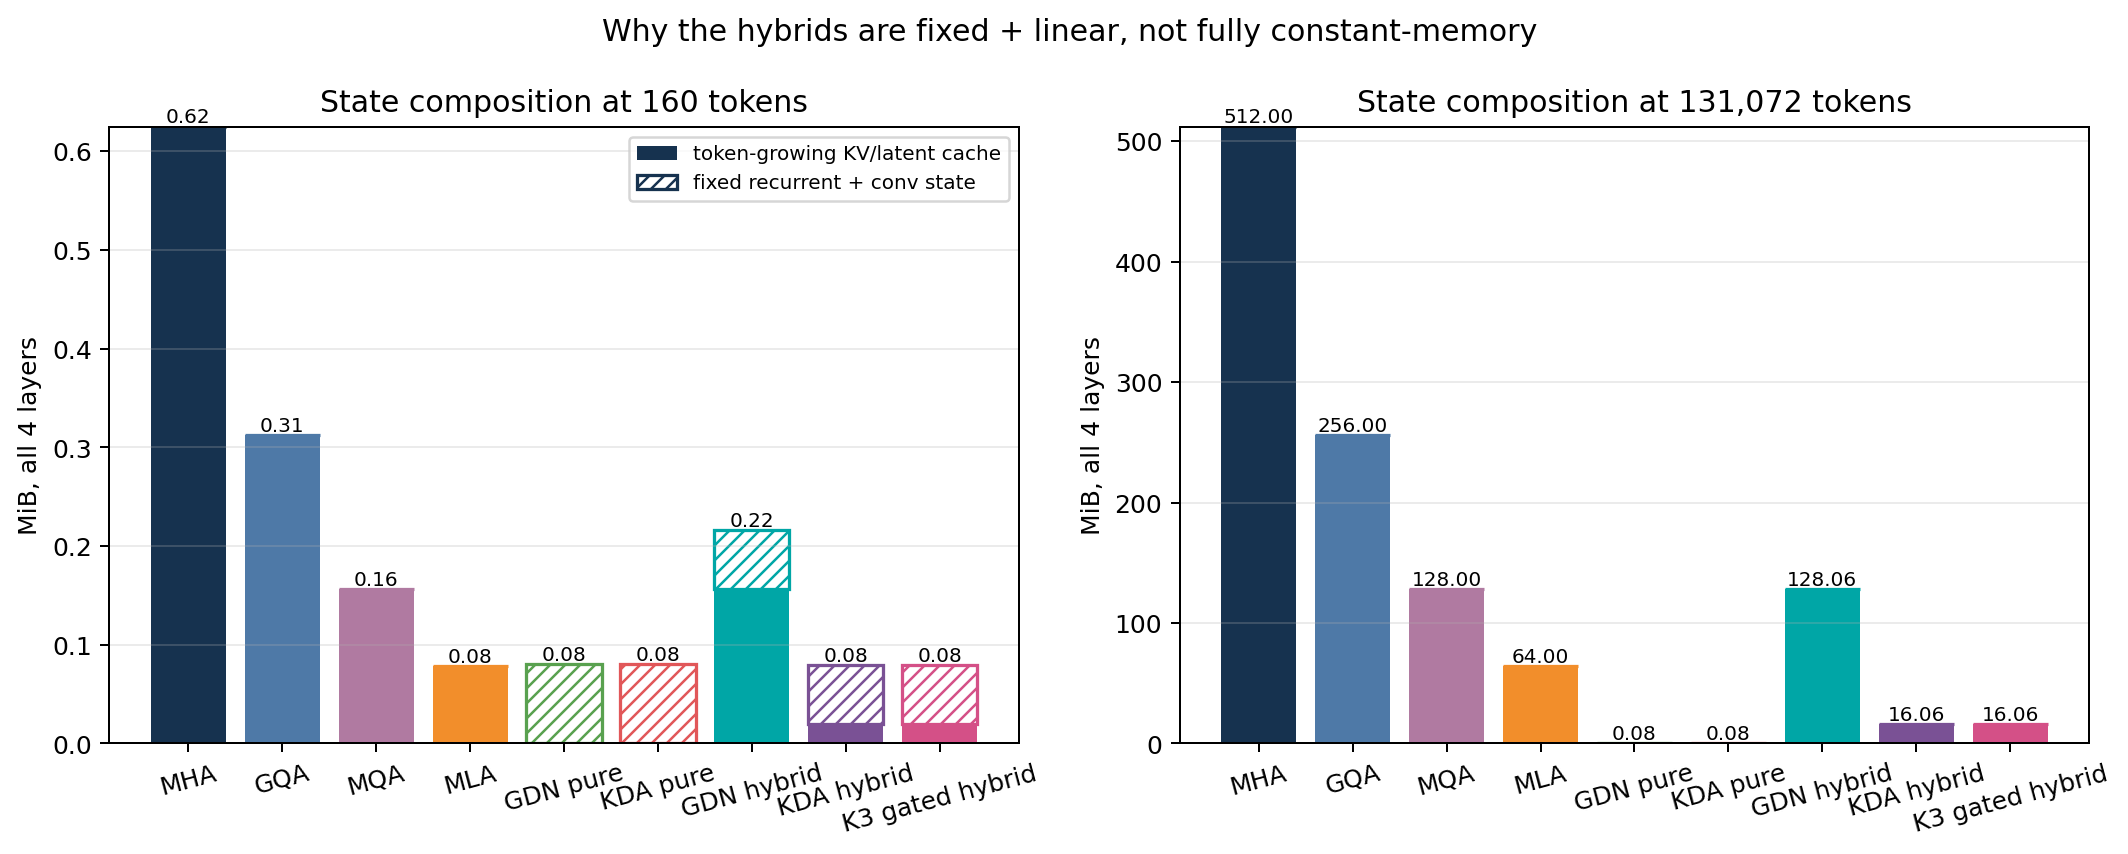

### Quality, memory, and reference-path throughput

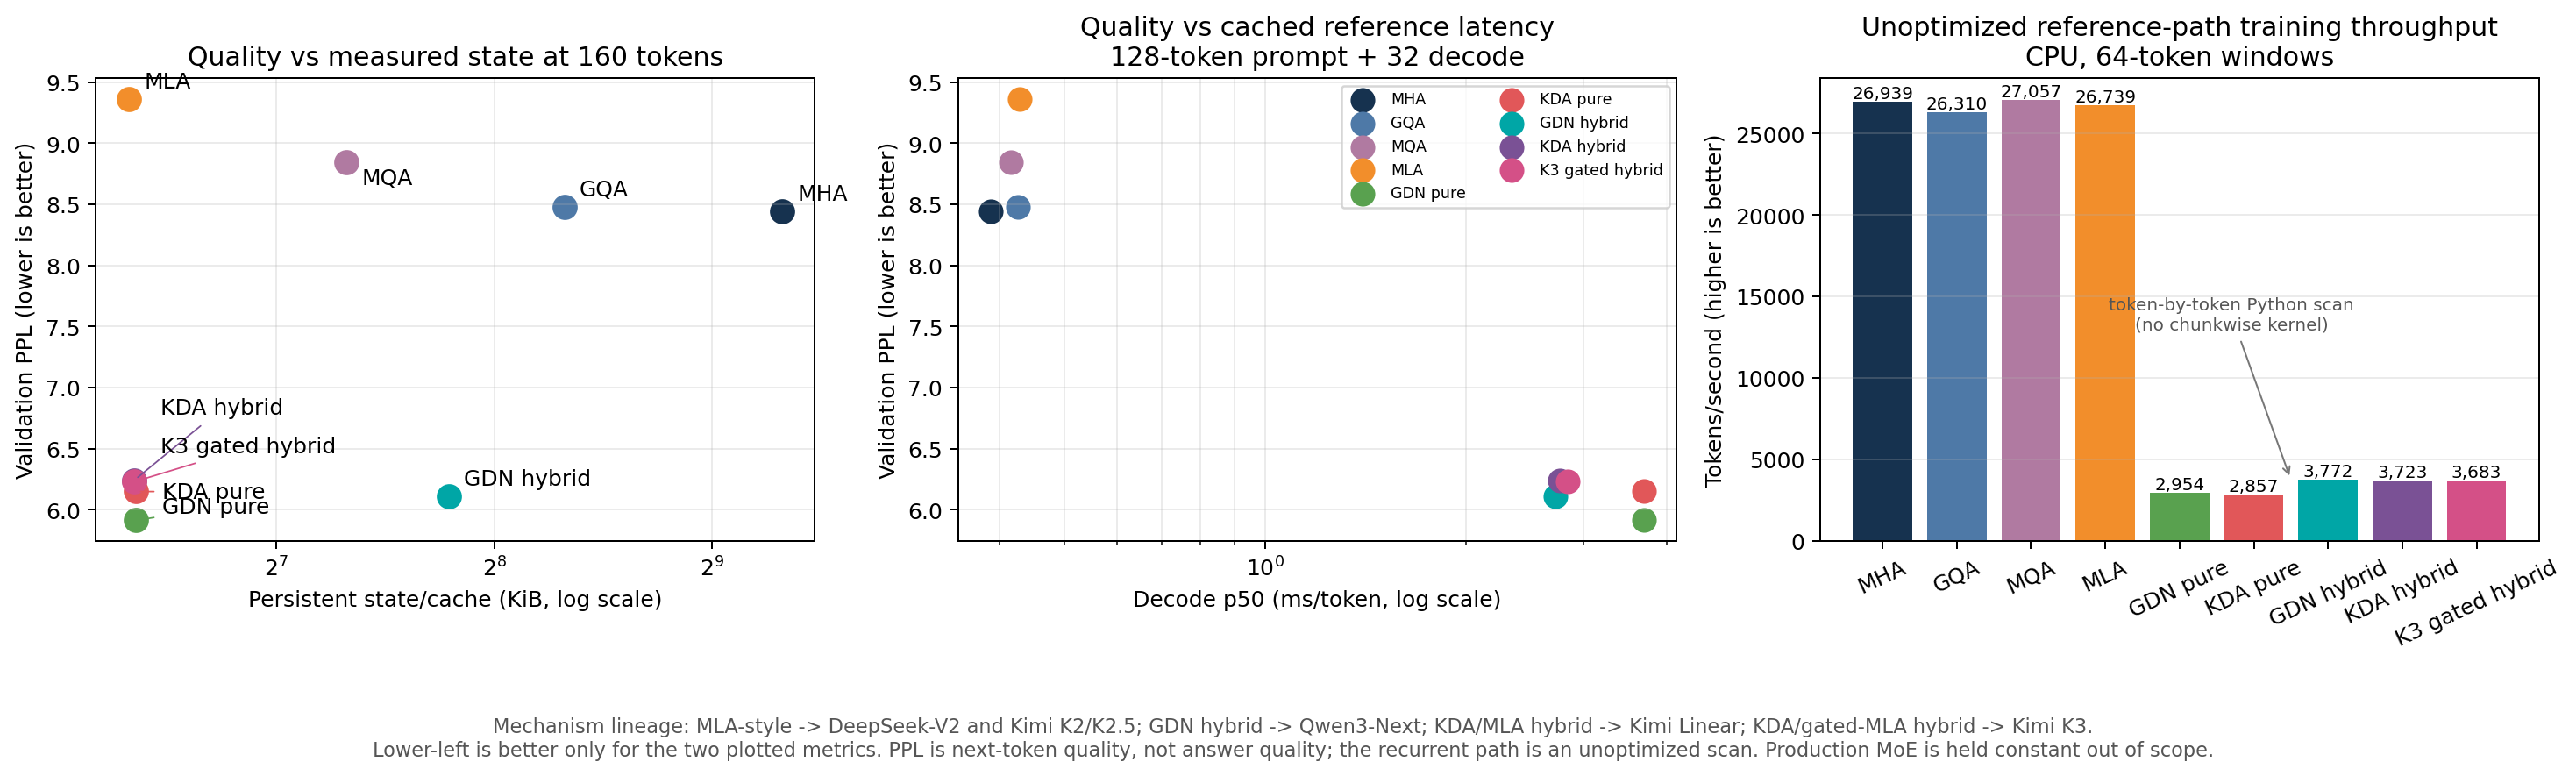

In [6]:
for title, filename in (
    ('State capacity and concurrency', 'hybrid_state_scaling.png'),
    ('Fixed versus token-growing state composition', 'hybrid_state_composition.png'),
    ('Quality, memory, and reference-path throughput', 'hybrid_quality_efficiency.png'),
):
    display(Markdown(f'### {title}'))
    display(Image(filename=FIGURE_DIR / filename))

## 8. Findings against the hypotheses

1. **Constant state — supported for the pure recurrent variants.** GDN and KDA each occupy 82.0 KiB at 160 tokens and remain at approximately 0.080 MiB in the 128K storage projection. MHA grows from 640 KiB at 160 tokens to 512 MiB at 128K.
2. **Hybrid scaling — supported.** The GDN/gated-MHA hybrid follows $62,976+1024T$ bytes. Both ungated and gated KDA/MLA hybrids follow $62,976+128T$ bytes and reach 16.06 MiB at 128K versus 64.00 MiB for four MLA-style layers: 3.99× smaller, approaching the expected 75% asymptotic reduction.
3. **Same state size, different forgetting — supported.** Pure GDN and KDA have identical persistent-state bytes. KDA spends additional gate capacity on channel-wise memory control rather than storage compression.
4. **KV-sharing ladder — supported for storage, with a small quality trade-off here.** At 160 tokens, measured state falls from MHA 640 KiB to GQA 320 KiB, MQA 160 KiB, and MLA-style 80 KiB. Their 128K projections are respectively 512, 256, 128, and 64 MiB, so every softmax variant still grows linearly. Validation PPL is 8.44, 8.48, 8.84, and 9.36 in the same order.
5. **Quality — promising but not conclusive.** GDN reaches 5.91 validation PPL, KDA 6.15, the GDN hybrid 6.11, the ungated KDA/MLA hybrid 6.24, and the gated K3-inspired hybrid 6.23. This run does not show a KDA advantage over GDN, and the result is confounded by parameter count, one seed, a character corpus, and one epoch.
6. **Gated MLA ablation — state law unchanged.** The gate adds 16,384 parameters but no persistent bytes: gated and ungated KDA/MLA hybrids both occupy 81.5 KiB at 160 tokens. PPL changes 6.24 → 6.23, training throughput 3,723 → 3,683 tok/s, and cached latency 2.763 → 2.838 ms/token; this is near-equivalence in one run, not a universal conclusion.
7. **Kernel boundary — strongly supported.** Cached recurrent decoding is about 3.70 ms/token for pure GDN/KDA versus 0.388 ms/token for MHA; GQA and MQA are also fast reference baselines at 0.426 and 0.415 ms/token. The readable sequential scan is roughly an order of magnitude slower even though it stores far less long-context state. This is a reference-implementation result, not evidence against optimized GDN/KDA kernels.

**Engineering conclusion:** recurrent delta attention changes the asymptotic storage law; hybridization restores an explicit full-history path at a controlled slope. Memory efficiency and kernel efficiency are separate experimental questions.

## 9. Evidence boundary

| Evidence level | What is supported | What is not claimed |
|---|---|---|
| **Measured** | One full epoch; validation PPL; CPU FP32 training throughput; prefill and decode at prompts 32/64/128; occupied state through 160 total tokens | CUDA ordering, production throughput, convergence, statistical significance |
| **Exact analytical projection** | `fixed_bytes + bytes_per_token × context`; state size and cache-only capacity through 128K | 128K latency, 128K PPL, allocation overhead, activation memory |
| **External published evidence** | MLA in DeepSeek-V2 and Kimi K2/K2.5; GDN and Qwen3-Next's 3:1 schedule; KDA/Kimi Linear; Kimi K3's launch-level 3:1 KDA/gated-MLA diagram | Reproduction of the published models, datasets, MoE systems, training recipes, or reported benchmark scores |

The project uses learned GPT-2 positional embeddings and a block size of 192. Therefore, the long-context lines are storage projections only. They are deliberately not presented as length-extrapolation experiments.

## 10. Limitations and threats to validity

- One seed, one small character-level corpus, one epoch, and models that are not trained to convergence.
- Parameter counts are reported but not matched: GDN/KDA have more token-mixer parameters than MHA/MLA-style.
- GDN and KDA use their respective output gates as well as different decay granularity, so their PPL gap cannot be attributed only to scalar versus channel-wise forgetting.
- The common AdamW group decays `A_log` and `dt_bias`, unlike the official no-decay grouping for those recurrent gate parameters.
- GQA and MQA were appended through deterministic resume in a second local session, and the Kimi-K3-inspired row in a later session, on the same recorded CPU configuration; small nine-way timing differences are not a strict single-session benchmark.
- CPU FP32 with one thread does not predict CUDA BF16/FP16 behavior. MHA uses optimized PyTorch matrix operations, while GDN/KDA deliberately use a Python token loop.
- The implementation omits the chunkwise WY/FLA training algorithm and FlashKDA kernels, so throughput is an implementation baseline rather than an architecture ceiling.
- The Qwen3-Next-inspired anchor is gated MHA in the shared GPT-2 skeleton; it does not reproduce Qwen3-Next's GQA dimensions, partial RoPE, zero-centered RMSNorm, MoE, MTP, or scale.
- The Kimi-Linear-inspired anchor is an explicit MLA-style latent cache; the Kimi-K3-inspired anchor adds our sigmoid output gate operationalization. Neither reproduces a complete Kimi model, training recipe, or deployment stack.
- MoE is deliberately held out: every variant uses the same dense GPT-2 MLP to isolate the token mixer. This preserves the persistent attention-state comparison, but changes total parameters, activated FLOPs, communication, optimization dynamics, peak memory, attainable quality, and end-to-end latency relative to production models.
- A fixed recurrent matrix can suffer memory collision on retrieval-heavy inputs even though its byte footprint is constant. Character-level PPL alone does not test that failure mode.
- Projections exclude weights, transient activations, kernel workspaces, allocator fragmentation, and multi-request scheduling overhead.

## 11. Next experiments

1. **MQAR / associative recall:** add Multi-Query Associative Recall and needle-style tasks with controlled distractor count, overwrite frequency, and sequence length. Measure retrieval accuracy, not only PPL, to expose fixed-state memory collision.
2. **Matched capacity:** train 3–5 seeds to convergence with matched total parameters and matched active FLOPs; report confidence intervals.
3. **Gate ablations:** scalar GDN decay versus channel-wise KDA decay, low-rank gate rank, short convolution on/off, output gate on/off, and FP32 versus lower-precision recurrent state.
4. **CUDA kernels:** replace the Python scan with official FLA chunkwise/fused-recurrent GDN and FlashKDA paths; benchmark BF16 prefill, decode, and memory on 1K–128K contexts.
5. **Hybrid sweeps:** compare 1:1, 3:1, and 7:1 recurrent/full schedules, with gated MHA, GQA, and MLA anchors under the same state budget.
6. **True long-context training:** replace learned absolute positions with a controlled positional design, train at longer windows, then measure long-context PPL and retrieval separately from storage projections.
7. **Serving metrics:** sweep batch size and concurrent sequences under a fixed memory budget; measure throughput, tail latency, and state-transfer cost.
8. **Factorial MoE control:** cross token mixer {MLA, GDN/KDA hybrid} with FFN {dense, sparse MoE} at matched active parameters/FLOPs to measure routing interactions separately from attention state.

## 12. What I implemented personally

- readable multi-head GDN and KDA recurrent scans from the published update rules;
- Mamba-style stable decay parameterization, scalar and low-rank channel-wise gates, L2-normalized Q/K, causal depthwise short convolutions, head-wise RMSNorm, and output gates;
- fixed recurrent/convolution cache objects and token-by-token cached inference;
- gated full-attention and MLA-style anchor layers plus three explicit 3:1 schedules, including a gated-versus-ungated MLA-anchor ablation;
- shared-backbone initialization, deterministic full-epoch data coverage, raw timing retention, and exact cache-layout accounting;
- correctness tests for causality, full-vs-cached equivalence, convolution history, hybrid schedules, and context-independent recurrent state;
- plots that distinguish executed measurements from analytical long-context storage projections.

**Interview summary:** I investigated when a Transformer-like system can replace a token-growing KV cache with recurrent state. I implemented GDN and KDA, then built Qwen3-Next-, Kimi-Linear-, and Kimi-K3-inspired 3:1 hybrids inside the same four-layer nanoGPT backbone. The gated MLA ablation preserved the exact state law and was nearly quality-neutral in this run, while the unoptimized recurrent path remained much slower on CPU. The next decisive test is retrieval quality with MQAR and production CUDA kernels.

## Reproduce from the project root

```bash
make test
make hybrid-experiment
make hybrid-plots
```

The committed JSON records the environment, dataset SHA-256, full configuration, training history, raw repeated timings, and exact state layout. This notebook intentionally defaults to `FORCE_RERUN = False`; change it only when a new full-epoch run is desired.